# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Lucie Klingens
* Username: lklingens
* Student number: s6390366
* Group (AS1, etc.): AS6

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

The first-order Taylor expansion for the gravitational acceleration of a pendulum is:
$$\sigma_g^2 = (\frac{\partial g}{\partial L})^2\sigma_L^2 + (\frac{\partial g}{\partial T})^2\sigma_T^2$$
The partial derivatives are:
$$\frac{\partial g}{\partial L} = \frac{\partial}{\partial L}(\frac{4\pi^2L}{T^2}) = \frac{4\pi^2}{T^2}$$
and
$$\frac{\partial g}{\partial T} = \frac{\partial}{\partial T}(\frac{4\pi^2L}{T^2}) = \frac{-8\pi^2L}{T^3}$$
Putting the partials into the error propagation formula gives:
$$\sigma_g^2 = (\frac{4\pi^2}{T^2})^2\sigma_L^2 + (\frac{-8\pi^2L}{T^3})^2\sigma_T^2$$ 
This formula can be rewritten as:
$$\sigma_g = \sqrt{((\frac{4\pi^2}{T^2})\sigma_L)^2+ ((\frac{-8\pi^2L}{T^3})\sigma_T)^2}$$ 
Here, $$\sigma_L$$ and $$\sigma_T$$ are the errors of the pendulum length L and the oscillation period T.

In [2]:
import numpy as np
import math

# Calculate g with the given formula and data.

L = 1.00  # Length in m
L_err = 0.01  # Error of length in m

T = 2.01  # Oscillation period in s
T_err = 0.02  # Error of period in s

g_calc = (4*np.pi**2*L)/(T**2)  # Formula for the acceleration g.

# Partial derivatives

partial_L = (4*np.pi**2)/(T**2)
partial_T = (-8*np.pi**2*L)/(T**3)

# Calculating the error of g with the formula stated above.

g_err = np.sqrt((partial_L*L_err)**2 + (partial_T*T_err)**2)

# Print g and its error (:.6g formats the numbers to have a maximum of 6 significant numbers).
print(f"The local gravitational acceleration g as calculated by the given formulae is: {g_calc:.6g} ± {g_err:.6g} m/s^2.\n")  # \n creates a new line, so there is space between two prints.

"""Apply Monte Carlo error propagation to estimate the value and uncertainty of g"""

N = 100000  # Amount of data points

# Define probability distributions based on measurement data.

L_samples = np.random.normal(1.00, 0.01, N)
T_samples = np.random.normal(2.01, 0.02, N)

g_MonteCarlo = (4*np.pi**2*L_samples)/(T_samples**2)  # Samples implemented in the function for g to get an array of g values.

g_MC_avg = np.mean(g_MonteCarlo)  # Calculate the mean of g = the average g.
g_MC_err = np.std(g_MonteCarlo)  # Calculate the standard deviation of g = the error of g.

print(f"The local gravitational acceleration g as calculated by Monte Carlo error propagation is: {g_MC_avg:.6g} ± {g_MC_err:.6g} m/s^2.\n")

# Comparing the two values of g by looking at the value of the difference between values.

diff = np.abs(g_MC_avg - g_calc)  # Calculate the difference.

if diff == 0:
    print(f"The two resulting values of the calculated g = {g_calc:.6g} m/s^2 and the Monte Carlo g = {g_MC_avg:.6g} m/s^2 are equal.")
elif diff < 0.001:
    print(f"The two resulting values of the calculated g = {g_calc:.6g} m/s^2 and the Monte Carlo g = {g_MC_avg:.6g} m/s^2 are equal up until three decimals.")
elif diff < 0.01:
    print(f"The two resulting values of the calculated g = {g_calc:.6g} m/s^2 and the Monte Carlo g = {g_MC_avg:.6g} m/s^2 are equal up until two decimals.")
elif diff < 0.1:
    print(f"The two resulting values of the calculated g = {g_calc:.6g} m/s^2 and the Monte Carlo g = {g_MC_avg:.6g} m/s^2 are equal up until one decimal.")

The local gravitational acceleration g as calculated by the given formulae is: 9.77164 ± 0.217631 m/s^2.

The local gravitational acceleration g as calculated by Monte Carlo error propagation is: 9.77479 ± 0.217413 m/s^2.

The two resulting values of the calculated g = 9.77164 m/s^2 and the Monte Carlo g = 9.77479 m/s^2 are equal up until two decimals.


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [4]:
import cmath  # For the calculations with complex terms
import math
import numpy as np

print("Give the values for the quadratic formula f(x) = ax^2 + bx + c")

# Enter the values of a, b and c

a = float(input("Enter a number for constant a:"))
b = float(input("Enter a number for constant b:"))
c = float(input("Enter a number for constant c:"))

D = (b**2) - 4*a*c  # Calculates the discriminant.
print(f"\nThe quadratic equation is: f(x) = {a}x^2 + {b}x + {c}, with discriminant {D}.\n")  # \n starts a new line, so there is a blank line between two prints

# Calculate the solutions of the quadratic formula and check whether the solutions give f(x) = 0 by recalculating f(x) for the solutions.

if D > 0:
    if a == 0:  # A special case of a == 0 results in a division by zero. In that case there is no solution to f.
        print("There is no solution of f(x).")
    else:
        x1 = (-b + math.sqrt(D))/(2*a)
        x2 = (-b - math.sqrt(D))/(2*a)
        function1 = a*(x1)**2 + b*x1 + c
        function2 = a*(x2)**2 + b*x2 + c
        print(f"There are two solutions of f(x): x ={x1:.4g} and x ={x2:.4g}.\n")  # :.4g formats the numbers to only show up to 4 significant numbers.
        print(f"Verify solutions by substituting back in f(x):")
        print(f"f({x1:.4g}) = {a}*{x1:.4g}^2 + {b}*{x1:.4g} + {c} = {function1:.4g}.")  
        print(f"f({x2:.4g}) = {a}*{x2:.4g}^2 + {b}*{x2:.4g} + {c} = {function2:.4g}.")
        if cmath.isclose(function1, 0, abs_tol=1e-1) and cmath.isclose(function2, 0, abs_tol=1e-1):  # Checks if the solution is close to zero, in case the number is not exaclty zero. 
            print("The solutions are indeed close to/equal to zero.")                                # abs_tol=1e-1 means that anything smaller than 0.1 is close to zero.
        else:
            print("The solutions are not close to/equal to zero.")
elif D == 0:
    x = x1 = x2 = (-b)/(2*a)
    result = x
    function = a*(x)**2 + b*x + c
    print(f"There is one solution of f(x): x ={x:.4g}.\n")
    print(f"Verify solution by substituting back in f(x):")
    print(f"f({x:.4g}) = {a}*{x:.4g}^2 + {b}*{x:.4g} + {c} = {function:.4g}.")
    if cmath.isclose(function, 0, abs_tol=1e-1):
        print("The solutions are indeed close to/equal to zero.")
    else:
        print("The solutions are not close to/equal to zero.")
elif D < 0:
    x1_c = (-b + cmath.sqrt(D))/(2*a)  # cmath.sqrt can calculate complex roots.
    x2_c = (-b - cmath.sqrt(D))/(2*a)
    function1_c = a*(x1_c)**2 + b*x1_c + c
    function2_c = a*(x2_c)**2 + b*x2_c + c
    print(f"There are two solutions of f(x): x1 ={x1_c:.4g} and x2 ={x2_c:.4g}.\n")
    print(f"Verify solutions by substituting back in f(x):")
    print(f"f({x1_c:.4g}) = {a}*{x1_c:.4g}^2 + {b}*{x1_c:.4g} + {c} = {function1_c:.4g}.")
    print(f"f({x2_c:.4g}) = {a}*{x2_c:.4g}^2 + {b}*{x2_c:.4g} + {c} = {function2_c:.4g}.")
    if cmath.isclose(function1_c, 0, abs_tol=1e-1) or cmath.isclose(function2_c, 0, abs_tol=1e-1):
        print("The solutions are indeed close to/equal to zero.")
    else:
        print("The solutions are not close to/equal to zero.")

Give the values for the quadratic formula f(x) = ax^2 + bx + c


Enter a number for constant a: 2
Enter a number for constant b: 3
Enter a number for constant c: 4



The quadratic equation is: f(x) = 2.0x^2 + 3.0x + 4.0, with discriminant -23.0.

There are two solutions of f(x): x1 =-0.75+1.199j and x2 =-0.75-1.199j.

Verify solutions by substituting back in f(x):
f(-0.75+1.199j) = 2.0*-0.75+1.199j^2 + 3.0*-0.75+1.199j + 4.0 = 4.441e-16+0j.
f(-0.75-1.199j) = 2.0*-0.75-1.199j^2 + 3.0*-0.75-1.199j + 4.0 = 4.441e-16+0j.
The solutions are indeed close to/equal to zero.


In [5]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

The area underneath the curve from x = 0 to x = 2.5 is 1.98 ± 2.19e-14.
The area underneath the curve from x = -inf to x = inf is 5.01 ± 6.33e-09.
The area underneath the curve from x = -inf to x = inf is 5.01.
The two area values between x = -inf and x = inf are equal.


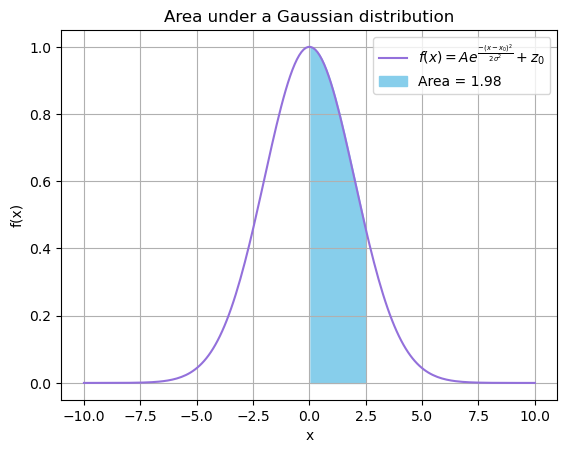

In [6]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import integrate
from math import inf

# Given constants

A = 1.0  # Amplitude
x0 = 0.0  # Maximum position
sigma = 2.0  # Maximum width
z0 = 0.0  # Offset in y

def gauss(x, A, x0, sigma, z0):
    """A function that calculates the above mentioned function for x"""
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

x = np.linspace(-10, 10, 200)  # Create 200 samples between -10 and 10.
y = gauss(x, A, x0, sigma, z0)  # User defined function with calling environment values for y.

# Calculate the area between x = 0 and x = 2.5.

area, error = integrate.quad(gauss, 0, 2.5, args=(A, x0, sigma, z0))  # quad() calculates the area and the uncertainty, so we assign area to the are and error to the uncertainty.
print(f"The area underneath the curve from x = 0 to x = 2.5 is {area:.3g} ± {error:.3g}.")  # :.3g formats to only show 3 significant numbers.

# Calculate the area between x = -inf and x = inf.

area_inf, error_inf = integrate.quad(gauss, -inf, inf, args=(A, x0, sigma, z0))
print(f"The area underneath the curve from x = -inf to x = inf is {area_inf:.3g} ± {error_inf:.3g}.") 

# Calculate area between x = -inf and x = inf using the formula.

area_int = A*sigma*np.sqrt(2*np.pi)
print(f"The area underneath the curve from x = -inf to x = inf is {area_int:.3g}.") 

# Check whether the two area's between x = -inf and x = inf are equal.

if math.isclose(area_inf, area_int, abs_tol=0.001):
    print("The two area values between x = -inf and x = inf are equal.")
else:
    print("The two area values between x = -inf and x = inf are not equal.")

# Plot the function

plt.plot(x, y, color='mediumpurple', label=r'$f(x)=Ae^{\frac{-(x-x_0)^2}{2\sigma^2}}+z_0$')
plt.fill_between(x, y, 0, where=(x >= 0)&(x <= 2.5), color='skyblue', label=f"Area = {area:.3g}")  # Fills the area under the curve for x values between 0 and 2.5
plt.title("Area under a Gaussian distribution")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.grid()
plt.legend(loc='upper right')  # Place legend in upper right corner.
plt.show()

Link to GitHub: https://github.com/lklingens/PROGNUM-repo.git 

The script can be found under \Task4\Python_scripts as gaussarea.py

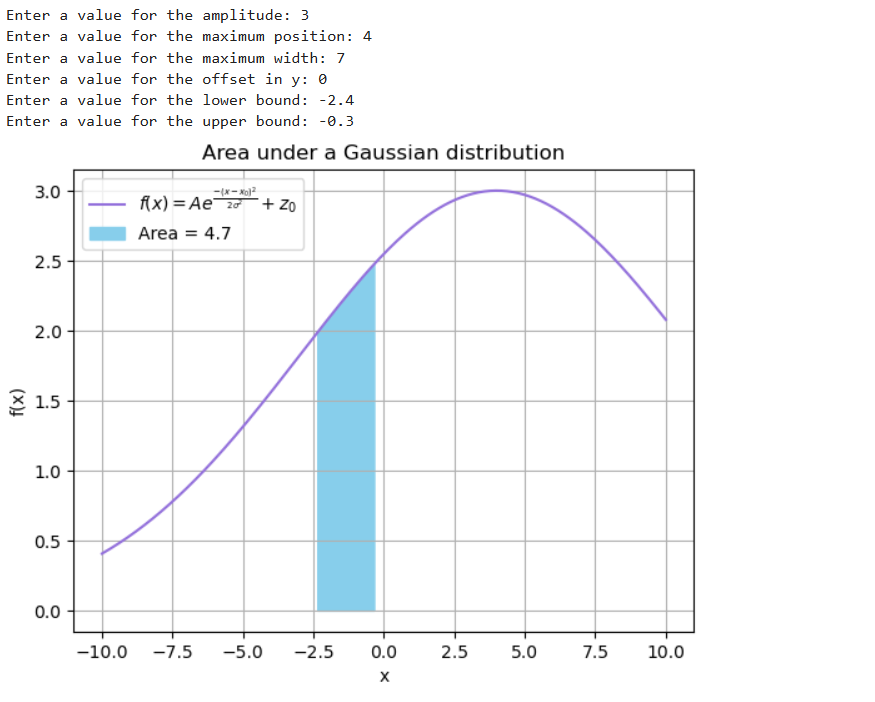

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [10]:
import numpy as np
from numpy import sin, cos, exp, pi  # Functions a user can apply.
from scipy import integrate

my_func = input("Enter a function f(x):")

def userfunc(x, my_func):
    """A function that evaluates the user input"""
    function = eval(my_func)  # Evaluates the input (string) as a function in order to be used in the integral.
    return function

# Calculate the integral between 0 and pi for a given function and return any exceptions for the input.

try:
    integral, error = integrate.quad(userfunc, 0, pi, args=my_func)  # quad() calculates the integral and its uncertainty, so we assign inegral to the value and error to the uncertainty.
    print(f"The integral of {my_func} from 0 to pi using quad() gives: {integral:.6g}.")
except NameError as E:
    print(f"NameError: {E}. Enter a function that is defined earlier or known in the NumPy library.")
except TypeError as E:
    print(f"TypeError: {E}. Use the correct mathematical symbols for your function, for example use ** instead of ^.")
except SyntaxError as E:
    print(f"SyntaxError: {E}. The structure of your input is not correct.")
except Exception as E:
    print(f"Error: {E}.")

def MonteCarlo(my_func, a, b, N=100000):
    """A function that applies the Monte Carlo Integration to a given function, for random numbers between a and b. Any errors are returned trough exceptions"""
    try:
        x = np.random.uniform(a, b, N) # N amount of uniformly distributed numbers between a and b.
        y = np.array(userfunc(x, my_func))  # By using the earlier defined function, Monte Carlo can be used for any function that is entered.
        integral= (b-a)*np.mean(y)  # The Monte Carlo integral
    except NameError as E:
        print(f"NameError: {E}. Enter a function that is defined earlier or known in the NumPy library.")
    except TypeError as E:
        print(f"TypeError: {E}. Use the correct mathematical symbols for your function, for example use ** instead of ^.")
    except SyntaxError as E:
        print(f"SyntaxError: {E}. The structure of your input is not correct.")
    except Exception as E:
        print(f"Error: {E}.")
    return integral

print(f"The integral of {my_func} from 0 to pi using Monte Carlo gives: {MonteCarlo(my_func, 0, np.pi):.6g}")  # :.4g formats the number to 4 significant digits

"""Note: the assignment mentions 'the formula below' multiple times, but I only see one: f(x) = x**4 + exp(sin(x)+cos(x)). Since that formula is the only one I see, that is the function I used to integrate from 0 to pi."""

Enter a function f(x): x


The integral of x from 0 to pi using quad() gives: 4.9348.
The integral of x from 0 to pi using Monte Carlo gives: 4.93607


"Note: the assignment mentions 'the formula below' multiple times, but I only see one: f(x) = x**4 + exp(sin(x)+cos(x)). Since that formula is the only one I see, that is the function I used to integrate from 0 to pi."

The script can be found under \Task4\Python_scripts as interate_user_function.py

In [22]:
import sympy as sp

x = sp.symbols('x')  # Define the symbol x, the variable in a function.
func = str(input("Enter a function f(x):"))  # Input any function that gets converted to a string.

# Calculate the integral of a given function from 0 to pi and return any errors of the input as exceptions.

try:
    integral2 = sp.integrate(func, (x, 0, sp.pi))  # Integrates an expression analytically, so needs a string function.
    print(f"The integral of {func} between 0 and pi is {integral2.evalf(6)}.")  # use evalf because the integral is a symbolic function (string input), 6 to format to 6 dignificant numbers.
except NameError as E:
    print(f"NameError: {E}. Enter a function that is defined earlier or known in the NumPy library.")
except TypeError as E:
    print(f"TypeError: {E}. Use the correct mathematical symbols for your function, for example use ** instead of ^.")
except SyntaxError as E:
    print(f"SyntaxError: {E}. The structure of your input is not correct.")
except Exception as E:
    print(f"Error: {E}.")

Enter a function f(x): x**4 + exp(sin(x)+cos(x))


The integral of x**4 + exp(sin(x)+cos(x)) between 0 and pi is 68.7293.


In [10]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

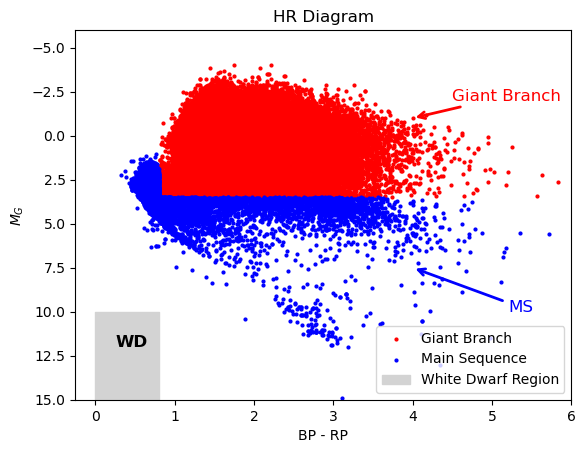

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

# Create a mask with the given criteria that can be used to mask the bad data.

mask = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

good_data = data[mask]  # Application of the mask to filter out the good data.

N = len(good_data)  # Length of good_data is how much stars we have in total.
random_ind = np.random.choice(N, int(0.8*N), replace=False)  # Randomly select 80% of the indices.
random_data = good_data[random_ind]  # Get the data from the good_data list by the indices.

# Define all needed data for further calculations from the random data.

parallax = random_data['GAIAEDR3_PARALLAX'] # Gaia parallax in milliarcseconds
m_G = random_data['GAIAEDR3_PHOT_G_MEAN_MAG'] # Apparent G-band magnitude
BP = random_data['GAIAEDR3_PHOT_BP_MEAN_MAG'] # BP magnitude
RP = random_data['GAIAEDR3_PHOT_RP_MEAN_MAG'] # RP magnitude

# Calculate colour, distance and absolute magnitude.

colour = BP - RP  # Calculate colour index BP-RP.
distance = 1000/parallax  # Convert parallax to distance in parsec.
abs_mag_G = m_G - 5*np.log10(distance)+5  # Absolute G-band magnitude

# Separate the Main Sequence from the Giant branch and the White Dwarfs using masks.

giants_mask = ((abs_mag_G < 3.5) & (colour > 0.8))
wd_mask = ((abs_mag_G > 10) & (colour <= 0.8))
MS_mask = ~(giants_mask | wd_mask)  # Everything that does not fit the Giants or White Dwarfs criteria belongs on the Main Sequence.

# Plot the HR-diagram, with color(BP-RP) on the x-axis and absolute magnitude on the y-axis.

plt.scatter(colour[giants_mask], abs_mag_G[giants_mask], s=4, color='red', label='Giant Branch')  # Plot the Giant Branch.
plt.scatter(colour[MS_mask], abs_mag_G[MS_mask], s=4, color='blue', label='Main Sequence')  # Plot the Main Sequence.

# Plot the White Dwarf region

plt.fill_betweenx([10, 20], 0, 0.8, color='lightgrey', label = 'White Dwarf Region') # Grey rectangle for WD region.
plt.text(0.25, 12, 'WD', fontsize=12, fontweight='bold')    # Label the box.

# Add arrows and text that point to the Giant Branch and the Main Sequence.

plt.annotate('Giant Branch', xy=(4, -1), xytext=(4.5, -2),
             color='red', fontsize=12,
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.annotate('MS', xy=(4, 7.5), xytext=(5.2,10),
             color='blue', fontsize=12,
             arrowprops=dict(arrowstyle='->', color='blue', lw=2))

# Set axis limits and invert the y-axis.

plt.xlim(-0.25,6)
plt.ylim(-6, 15)
plt.gca().invert_yaxis() # Invert y-axis so that brighter stars appear higher on the diagram.

# Create axis labels and the title.

plt.xlabel('BP - RP')
plt.ylabel(r'$M_G$')
plt.title('HR Diagram')

plt.legend(loc='lower right')
plt.show()

In [12]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [13]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 26. Student score: 0.0.  Task Grade = 0.0
